### Simulação de Efeitos de Tratamento heterogêneos

Etapas e Intuições da Simulação

1. Carregamento e preparação do shapefile; 
   1. Carrega um arquivo geográfico dos municípios do Brasil (.shp).
   2. Extrai a geometria e calcula os centroides (lat, lon) de cada município, necessários para criar a matriz de vizinhança espacial.

2. Geração das covariáveis iniciais (X1, X2, X3)
Gera variáveis socioeconômicas simuladas de forma aleatória para cada município.
   1. Cada variável possui uma tendência temporal heterogênea, ou seja, evolui no tempo com diferentes intensidades por município.

3. Construção do painel 2000–2024
   1. Cria uma base em painel com todos os municípios e todos os anos entre 2000 e 2024.
   2. Atualiza os valores de X1, X2 e X3 ano a ano com base nas tendências simuladas.

4. Atribuição de tratamento
   1. Simula a probabilidade de cada município receber um tratamento (por exemplo, instalação de usina ou política pública), com base nas covariáveis.
   2. Para os municípios tratados, sorteia aleatoriamente o ano de início do tratamento entre 2005 e 2020.
   3. Define uma variável binária D, que vale 1 se o município está tratado no ano t, e 0 caso contrário.

5. Matriz de vizinhança espacial (W)
   1. Cria uma matriz de vizinhança espacial (Queen contiguity), onde municípios são vizinhos se compartilham fronteiras.
   2. Essa matriz será usada para calcular o efeito de spillover (efeito indireto do tratamento em municípios vizinhos).

6. Criação de um índice socioeconômico (X_index)
   1. Em cada ano, combina as covariáveis de forma não linear e interativa (com pesos diferentes) para gerar um índice sintético que representa as condições socioeconômicas do município.
   2. Esse índice será usado para ponderar o efeito de spillover.

7. Cálculo do spillover espacial
   1. Para cada ano:
   2. Calcula o número de vizinhos tratados.
   3. Multiplica esse número pelo índice socioeconômico ponderado de cada município.
   4. Isso gera uma variável chamada spillover, que representa efeitos indiretos do tratamento recebidos via vizinhança.

8. Geração da variável de desfecho (Y)
   1. Define a função de geração do resultado $Y_{it}$ como uma combinação dos seguintes componentes:
      1. Covariáveis (X1, X2, X3)
      2. Efeito direto do tratamento ($\beta$)
      3. Efeito de spillover ($\gamma$)
      4. Efeitos fixos de município ($\alpha_i$) e ano ($\lambda_t$)
      5. Ruído aleatório ($\varepsilon_{it}$)

In [1]:
import pandas as pd
import geopandas as gpd
import numpy as np
from libpysal.weights import Queen
from sklearn.preprocessing import MinMaxScaler

# === Etapa 1: Carregar shapefile dos municípios do Brasil ===
shapefile_path = "C:/Users/danie/OneDrive/Área de Trabalho/BR_Municipios_2024.shp"
gdf = gpd.read_file(shapefile_path)

# Selecionar e renomear colunas principais
gdf = gdf[['CD_MUN', 'NM_MUN', 'SIGLA_UF', 'geometry']].copy()
gdf = gdf.rename(columns={'CD_MUN': 'codmun', 'NM_MUN': 'municipio', 'SIGLA_UF': 'uf'})

# Calcular centroides
gdf['lat'] = gdf.geometry.centroid.y
gdf['lon'] = gdf.geometry.centroid.x

# === Etapa 2: Simular covariáveis iniciais e suas tendências ===
np.random.seed(42)
n_mun = gdf.shape[0]
gdf['X1'] = np.random.normal(0, 1, n_mun)
gdf['X2'] = np.random.normal(0, 1, n_mun)
gdf['X3'] = np.random.normal(0, 1, n_mun)

# Tendência de crescimento heterogênea
gdf['X1_trend'] = np.random.normal(0.01, 0.005, n_mun)
gdf['X2_trend'] = np.random.normal(0.02, 0.007, n_mun)
gdf['X3_trend'] = np.random.normal(0.015, 0.004, n_mun)

# === Etapa 3: Expandir painel 2000–2024 com evolução dos X ===
years = list(range(2000, 2025))
panel = pd.DataFrame(
    [(row.codmun, row.municipio, row.uf,
      row.X1 + (year - 2000) * row.X1_trend,
      row.X2 + (year - 2000) * row.X2_trend,
      row.X3 + (year - 2000) * row.X3_trend,
      row.lat, row.lon, year)
     for idx, row in gdf.iterrows() for year in years],
    columns=['codmun', 'municipio', 'uf', 'X1', 'X2', 'X3', 'lat', 'lon', 'year']
)

# === Etapa 4: Atribuir tratamento baseado em X1, X2, X3 ===
gdf['prob_treat'] = 1 / (1 + np.exp(- (1.5 * gdf['X1'] + 1.0 * gdf['X2'] + 0.5 * gdf['X3'])))
gdf['treated'] = np.random.binomial(1, gdf['prob_treat'])
treated_muns = gdf.loc[gdf['treated'] == 1, 'codmun'].values
treatment_years = {mun: np.random.randint(2005, 2021) for mun in treated_muns}
panel['treat_year'] = panel['codmun'].map(treatment_years)
panel['D'] = ((panel['treat_year'].notnull()) & (panel['year'] >= panel['treat_year'])).astype(int)

# Calcular anos desde tratamento (para efeitos dinâmicos)
panel['years_treated'] = (panel['year'] - panel['treat_year']).clip(lower=0)
panel['years_treated'] = panel['years_treated'].where(panel['D'] == 1, 0)
panel['treatment_effect'] = panel['years_treated'].clip(upper=3)  # efeito cresce nos 3 primeiros anos

# === Etapa 5: Matriz de vizinhança espacial ===
w = Queen.from_dataframe(gdf)
W_sparse = w.full()[0]

# === Etapa 6: Recalcular índice socioeconômico por ano (com interações complexas) ===
panel['X_index'] = 0.0
for year in years:
    df_year = panel.loc[panel['year'] == year, ['X1', 'X2', 'X3']]
    scaler = MinMaxScaler()
    X_scaled = scaler.fit_transform(df_year)
    X1s = X_scaled[:, 0]
    X2s = X_scaled[:, 1]
    X3s = X_scaled[:, 2]

    # Índice complexo com pesos: 0.5 para soma linear, 0.3 para interação simples, 0.2 para interação não linear
    X_index_new = (
        0.5 * (X1s + X2s + X3s) +
        0.3 * (X1s * X2s) +
        0.2 * (X1s**2 * X2s * X3s)
    )
    panel.loc[panel['year'] == year, 'X_index'] = X_index_new

# === Etapa 7: Calcular spillover condicional ===
panel['spillover'] = 0.0
for year in years:
    Dt = panel.loc[panel['year'] == year, ['codmun', 'D']].set_index('codmun')
    D_vector = gdf['codmun'].map(Dt['D']).fillna(0).values.reshape(-1, 1)
    spill_raw = W_sparse @ D_vector
    spill_strength = spill_raw.flatten() * panel.loc[panel['year'] == year, 'X_index'].values
    panel.loc[panel['year'] == year, 'spillover'] = spill_strength

# === Etapa 8: Gerar variável de resultado Y ===
np.random.seed(42)
panel['alpha_i'] = panel['codmun'].astype('category').cat.codes * 0.02
panel['lambda_t'] = (panel['year'] - 2000) * 0.01
panel['epsilon'] = np.random.normal(0, 0.3, panel.shape[0])

# Coeficientes de impacto
beta = 1.5  # efeito direto
gamma = 0.8  # efeito spillover

# Função de geração do desfecho com efeito dinâmico
panel['Y'] = (
    2 +
    0.6 * panel['X1'] +
    0.4 * panel['X2'] +
    0.2 * panel['X3'] +
    beta * panel['treatment_effect'] +
    gamma * panel['spillover'] +
    panel['alpha_i'] +
    panel['lambda_t'] +
    panel['epsilon']
)

C:\Users\danie\AppData\Local\Temp\ipykernel_17864\113429467.py:57: FutureWarning: `use_index` defaults to False but will default to True in future. Set True/False directly to control this behavior and silence this warning
  w = Queen.from_dataframe(gdf)
c:\Users\danie\AppData\Local\Programs\Python\Python310\lib\site-packages\libpysal\weights\contiguity.py:347: UserWarning: The weights matrix is not fully connected: 
 There are 3 disconnected components.
 There are 2 islands with ids: 3909, 4656.
  W.__init__(self, neighbors, ids=ids, **kw)


In [2]:
panel

,codmun,municipio,uf,X1,X2,X3,lat,lon,year,treat_year,D,years_treated,treatment_effect,X_index,spillover,alpha_i,lambda_t,epsilon,Y
0,2504108,Carrapateira,PB,0.496714,-0.374534,-0.693767,-7.044461,-38.337539,2000,2013.0,0,0.0,0.0,0.763956,0.000000,25.92,0.00,0.149014,28.078476
1,2504108,Carrapateira,PB,0.509975,-0.364755,-0.676933,-7.044461,-38.337539,2001,2013.0,0,0.0,0.0,0.763261,0.000000,25.92,0.01,-0.041479,27.913217
2,2504108,Carrapateira,PB,0.523236,-0.354976,-0.660099,-7.044461,-38.337539,2002,2013.0,0,0.0,0.0,0.762562,0.000000,25.92,0.02,0.194307,28.174238
3,2504108,Carrapateira,PB,0.536497,-0.345197,-0.643265,-7.044461,-38.337539,2003,2013.0,0,0.0,0.0,0.761862,0.000000,25.92,0.03,0.456909,28.462075
4,2504108,Carrapateira,PB,0.549758,-0.335418,-0.626431,-7.044461,-38.337539,2004,2013.0,0,0.0,0.0,0.761160,0.000000,25.92,0.04,-0.070246,27.960155
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139320,1707405,Esperantina,TO,-0.225178,1.704674,-0.769207,-5.326292,-48.540319,2020,2006.0,1,14.0,3.0,0.793744,1.587489,7.18,0.20,-0.072299,15.470613
139321,1707405,Esperantina,TO,-0.219234,1.744992,-0.764597,-5.326292,-48.540319,2021,2006.0,1,15.0,3.0,0.793895,1.587790,7.18,0.21,0.176321,15.750090
139322,1707405,Esperantina,TO,-0.213290,1.785311,-0.759987,-5.326292,-48.540319,2022,2006.0,1,16.0,3.0,0.794045,1.588091,7.18,0.22,-0.350975,15.253651
139323,1707405,Esperantina,TO,-0.207346,1.825629,-0.755377,-5.326292,-48.540319,2023,2006.0,1,17.0,3.0,0.794195,1.588391,7.18,0.23,-0.584062,15.051420


### Verificando modelos em busca do efeito do tratamento

In [3]:
import statsmodels.api as sm

# Regressão linear simples: Y ~ D
df_reg = panel.copy()

X = sm.add_constant(df_reg['D'])  # adiciona intercepto
y = df_reg['Y']

model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.004
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     608.2
Date:                qua, 02 jul 2025   Prob (F-statistic):          5.24e-134
Time:                        17:22:43   Log-Likelihood:            -6.8148e+05
No. Observations:              139325   AIC:                         1.363e+06
Df Residuals:                  139323   BIC:                         1.363e+06
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         58.7153      0.100    588.547      0.0

In [4]:
X = sm.add_constant(df_reg[['D', 'X1', 'X2', 'X3']])  # adiciona intercepto
y = df_reg['Y']

model2 = sm.OLS(y, X).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.006
Model:                            OLS   Adj. R-squared:                  0.006
Method:                 Least Squares   F-statistic:                     201.7
Date:                qua, 02 jul 2025   Prob (F-statistic):          7.72e-173
Time:                        17:23:09   Log-Likelihood:            -6.8138e+05
No. Observations:              139325   AIC:                         1.363e+06
Df Residuals:                  139320   BIC:                         1.363e+06
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         58.6928      0.101    583.105      0.0

#### TWFE

In [ ]:
from pyfixest.estimation import feols
twfe_model = feols("Y ~ D | year + codmun", data=panel)
print(twfe_model.summary())

###

Estimation:  OLS
Dep. var.: Y, Fixed effects: year+codmun
Inference:  CRV1
Observations:  139325

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| D             |      3.568 |        0.210 |    17.003 |      0.000 |  3.135 |   4.001 |
---
RMSE: 0.911 R2: 0.999 R2 Within: 0.525 
None


In [22]:
twfe_model2 = feols("Y ~ D + X1 + X2 + X3| year + codmun", data=panel)
print(twfe_model2.summary())

###

Estimation:  OLS
Dep. var.: Y, Fixed effects: year+codmun
Inference:  CRV1
Observations:  139325

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| D             |      3.568 |        0.210 |    16.994 |      0.000 |  3.135 |   4.002 |
| X1            |      1.015 |        0.065 |    15.500 |      0.000 |  0.880 |   1.150 |
| X2            |      0.774 |        0.033 |    23.486 |      0.000 |  0.706 |   0.842 |
| X3            |      0.028 |        0.082 |     0.339 |      0.737 | -0.142 |   0.197 |
---
RMSE: 0.909 R2: 0.999 R2 Within: 0.526 
None


### Diferença em Diferença Espacial (Spatial DiD) conforme Delgado e Florax (2015)

O modelo clássico a ser estimado é:

$$ Y_{it} = \alpha_i + \lambda_t + \beta D_{it} + \gamma W D_{it} + \epsilon_{it} $$

Ou seja, precisamos:

- Y: resultadi
- D: variável de tratamento
- WD: spillover espacial, que precisa ser calculado com base na vizinhança espacial (matriz W) e a variável D
- Efeitos fixos: município (codmun) e tempo (year)


In [80]:
# === Construir variável WD (spillover espacial) ===
from scipy.sparse import csr_matrix

panel['WD'] = 0.0  # inicializa

for year in years:
    # D para o ano atual
    D_year = panel.loc[panel['year'] == year, ['codmun', 'D']].set_index('codmun')
    D_vector = gdf['codmun'].map(D_year['D']).fillna(0).values.reshape(-1, 1)  # ordena como no gdf
    WD_vector = W_sparse @ D_vector
    panel.loc[panel['year'] == year, 'WD'] = WD_vector.flatten()


In [81]:
import statsmodels.formula.api as smf

# Converte para categoria para gerar dummies automaticamente
panel['codmun'] = panel['codmun'].astype('category')
panel['year'] = panel['year'].astype('category')

# Regressão com efeitos fixos + D + WD
model = smf.ols('Y ~ D + WD + C(codmun) + C(year)', data=panel)
results = model.fit(cov_type='cluster', cov_kwds={'groups': panel['codmun']})  # Erros clusterizados por município

print(results.summary())

c:\Users\danie\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5598, but rank is 5527
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.998
Model:                            OLS   Adj. R-squared:                  0.998
Method:                 Least Squares   F-statistic:                 5.075e+08
Date:                qua, 02 jul 2025   Prob (F-statistic):               0.00
Time:                        16:46:58   Log-Likelihood:            -2.5832e+05
No. Observations:              139325   AIC:                         5.278e+05
Df Residuals:                  133726   BIC:                         5.830e+05
Df Model:                        5598                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                3.0758 

Adicionando covariáveis:

$$ Y_{it} = \alpha_i + \lambda_t + \beta D_{it} + \gamma W D_{it} + \delta X_{it} + \epsilon_{it} $$


In [82]:
# Regressão com efeitos fixos e covariáveis: + D + WD + X1 + X2 + X3
model2 = smf.ols('Y ~ D + WD + C(codmun) + C(year) + X1 + X2 + X3', data=panel)
results2 = model2.fit(cov_type='cluster', cov_kwds={'groups': panel['codmun']})  # Erros clusterizados por município

print(results2.summary())

c:\Users\danie\AppData\Local\Programs\Python\Python310\lib\site-packages\statsmodels\base\model.py:1894: ValueWarning: covariance of constraints does not have full rank. The number of constraints is 5601, but rank is 29
  warnings.warn('covariance of constraints does not have full '


                            OLS Regression Results                            
Dep. Variable:                      Y   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 1.612e+14
Date:                qua, 02 jul 2025   Prob (F-statistic):               0.00
Time:                        17:03:12   Log-Likelihood:            -1.6065e+05
No. Observations:              139325   AIC:                         3.325e+05
Df Residuals:                  133723   BIC:                         3.876e+05
Df Model:                        5601                                         
Covariance Type:              cluster                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                1.7605 

#### Gardner et al. (2022)

In [5]:
import pyfixest as pf

# Estima o modelo de Gardner (did2s) com covariáveis
fit_gardner = pf.did2s(
    data=panel,
    yname="Y",                     # variável dependente
    treatment="D",                # dummy de tratamento
    first_stage="~ X1 + X2 + X3 | codmun + year",  # controles + efeitos fixos
    second_stage="~ D",           # variável de interesse
    cluster="codmun"              # erro padrão clusterizado
)

# Exibe os resultados
print(fit_gardner.summary())

###

Estimation:  DID2S
Dep. var.: Y_hat, Fixed effects: 0
Inference:  CRV1 (GMM)
Observations:  139325

| Coefficient   |   Estimate |   Std. Error |   t value |   Pr(>|t|) |   2.5% |   97.5% |
|:--------------|-----------:|-------------:|----------:|-----------:|-------:|--------:|
| D             |      4.024 |        0.020 |   202.803 |      0.000 |  3.986 |   4.063 |
---
RMSE: 0.992 R2: 0.756 
None


#### Callaway & Sant'Anna (2021)








In [6]:
# retirar os warnings
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LassoCV, LogisticRegressionCV

from doubleml.data import DoubleMLPanelData
from doubleml.did import DoubleMLDIDMulti

In [7]:
# Set values for treatment group indicator for never-treated to np.inf
panel.loc[panel['treat_year'] == 0, 'treat_year'] = np.inf

In [ ]:
panel['treat_year'] = panel['treat_year'].fillna(np.inf)

In [ ]:
panel = panel.sort_values(by=['treat_year', 'year']).reset_index(drop=True)

In [28]:
dml_data = DoubleMLPanelData(
    data=panel,
    y_col="Y",
    d_cols="treat_year",
    id_col="codmun",
    t_col="year",
    x_cols=['X1', 'X2', 'X3']
)
print(dml_data)

================== DoubleMLPanelData Object ==================

------------------ Data summary      ------------------
Outcome variable: Y
Treatment variable(s): ['treat_year']
Covariates: ['X1', 'X2', 'X3']
Instrument variable(s): None
Time variable: year
Id variable: codmun
No. Observations: 5573

------------------ DataFrame info    ------------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139325 entries, 0 to 139324
Columns: 19 entries, codmun to Y
dtypes: float64(14), int64(2), object(3)
memory usage: 20.2+ MB



In [29]:
dml_obj = DoubleMLDIDMulti(
    obj_dml_data=dml_data,
    ml_g=DummyRegressor(),
    ml_m=DummyClassifier(),
    control_group="never_treated",
    n_folds=10
)

dml_obj.fit()
print(dml_obj.summary.round(4))

                         coef  std err         t   P>|t|   2.5 %  97.5 %
ATT(2005.0,2000,2001)  0.0376   0.0327    1.1498  0.2502 -0.0265  0.1016
ATT(2005.0,2001,2002) -0.0293   0.0348   -0.8415  0.4001 -0.0976  0.0390
ATT(2005.0,2002,2003)  0.0009   0.0325    0.0291  0.9767 -0.0628  0.0647
ATT(2005.0,2003,2004) -0.0280   0.0305   -0.9179  0.3587 -0.0877  0.0318
ATT(2005.0,2004,2005)  0.0069   0.0382    0.1809  0.8564 -0.0680  0.0819
...                       ...      ...       ...     ...     ...     ...
ATT(2020.0,2019,2020)  0.0649   0.0391    1.6611  0.0967 -0.0117  0.1415
ATT(2020.0,2019,2021)  1.5535   0.0401   38.7218  0.0000  1.4748  1.6321
ATT(2020.0,2019,2022)  3.0431   0.0383   79.5110  0.0000  2.9681  3.1182
ATT(2020.0,2019,2023)  4.5356   0.0424  107.0744  0.0000  4.4526  4.6186
ATT(2020.0,2019,2024)  4.5220   0.0382  118.2398  0.0000  4.4471  4.5970

[384 rows x 6 columns]


In [30]:
level = 0.95

ci = dml_obj.confint(level=level)
dml_obj.bootstrap(n_rep_boot=5000)
ci_joint = dml_obj.confint(level=level, joint=True)
print(ci_joint)

                          2.5 %    97.5 %
ATT(2005.0,2000,2001) -0.085447  0.160597
ATT(2005.0,2001,2002) -0.160439  0.101818
ATT(2005.0,2002,2003) -0.121437  0.123332
ATT(2005.0,2003,2004) -0.142749  0.086785
ATT(2005.0,2004,2005) -0.137063  0.150904
...                         ...       ...
ATT(2020.0,2019,2020) -0.082177  0.211974
ATT(2020.0,2019,2021)  1.402431  1.704486
ATT(2020.0,2019,2022)  2.899067  3.187230
ATT(2020.0,2019,2023)  4.376149  4.695076
ATT(2020.0,2019,2024)  4.378074  4.666021

[384 rows x 2 columns]


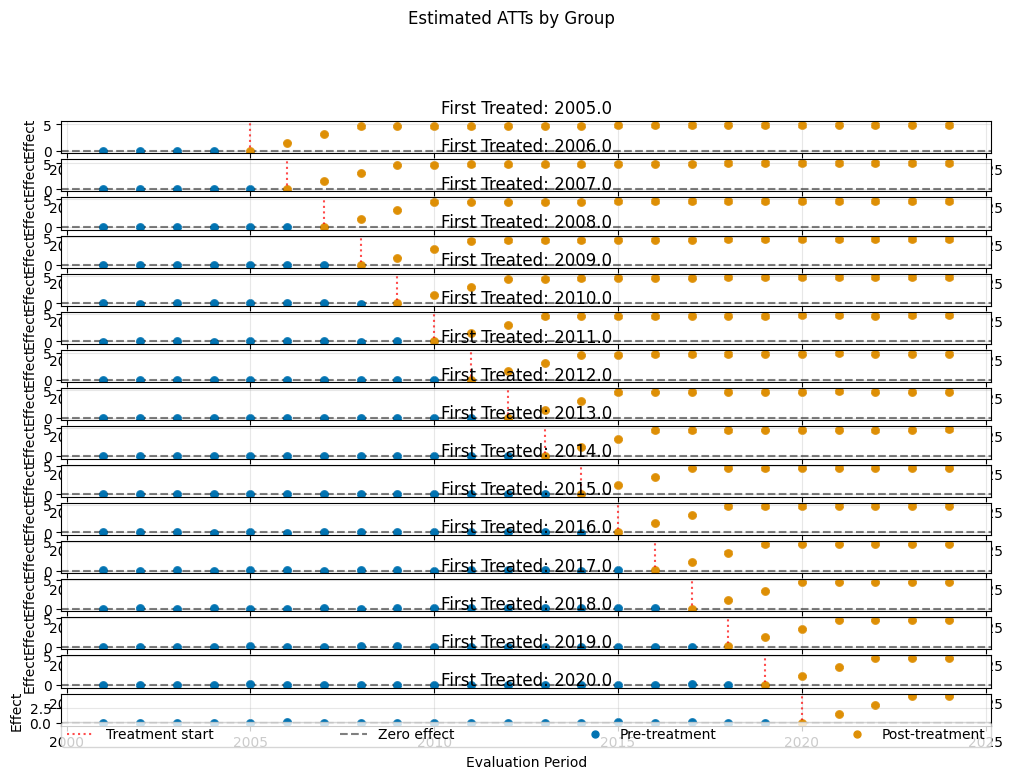

In [31]:
fig, ax = dml_obj.plot_effects()

================== DoubleMLDIDAggregation Object ==================
 Event Study Aggregation 

------------------ Overall Aggregated Effects ------------------
    coef  std err          t  P>|t|    2.5 %   97.5 %
4.293503  0.02461 174.463245    0.0 4.245269 4.341737
------------------ Aggregated Effects         ------------------
           coef   std err           t     P>|t|     2.5 %    97.5 %
-19.0 -0.007212  0.029702   -0.242800  0.808160 -0.065426  0.051003
-18.0  0.016617  0.023092    0.719625  0.471756 -0.028642  0.061876
-17.0 -0.000429  0.020931   -0.020483  0.983658 -0.041454  0.040596
-16.0 -0.024122  0.016979   -1.420707  0.155402 -0.057400  0.009156
-15.0  0.016463  0.015758    1.044727  0.296149 -0.014423  0.047349
-14.0  0.023630  0.014072    1.679266  0.093100 -0.003950  0.051211
-13.0  0.017293  0.013410    1.289549  0.197207 -0.008990  0.043575
-12.0  0.018413  0.012916    1.425579  0.153990 -0.006902  0.043728
-11.0 -0.009245  0.012139   -0.761609  0.446293 -0.0330

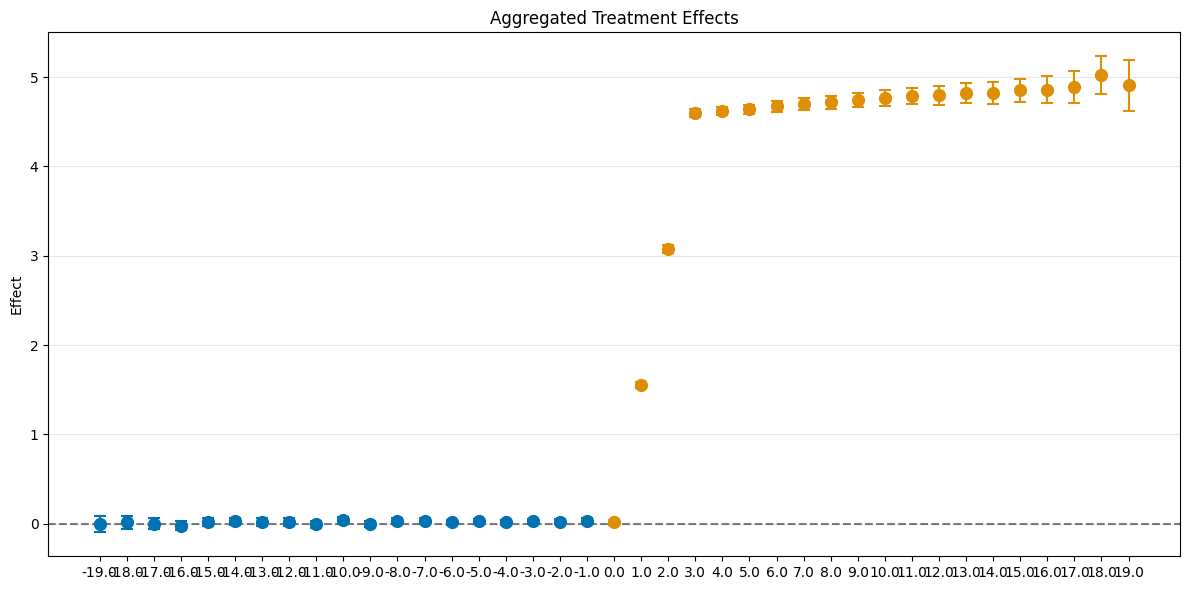

In [32]:
# rerun bootstrap for valid simultaneous inference (as values are not saved)
dml_obj.bootstrap(n_rep_boot=5000)
aggregated_eventstudy = dml_obj.aggregate("eventstudy")
# run bootstrap to obtain simultaneous confidence intervals
aggregated_eventstudy.aggregated_frameworks.bootstrap()
print(aggregated_eventstudy)
fig, ax = aggregated_eventstudy.plot_effects()

In [33]:
aggregated_eventstudy.aggregation_weights[2]

array([0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.        , 0.        , 0.     

(<Figure size 1200x800 with 17 Axes>,
 [<Axes: title={'center': 'First Treated: 2005.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2006.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2007.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2008.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2009.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2010.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2011.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2012.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2013.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2014.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2015.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2016.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2017.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2018.0'}, 

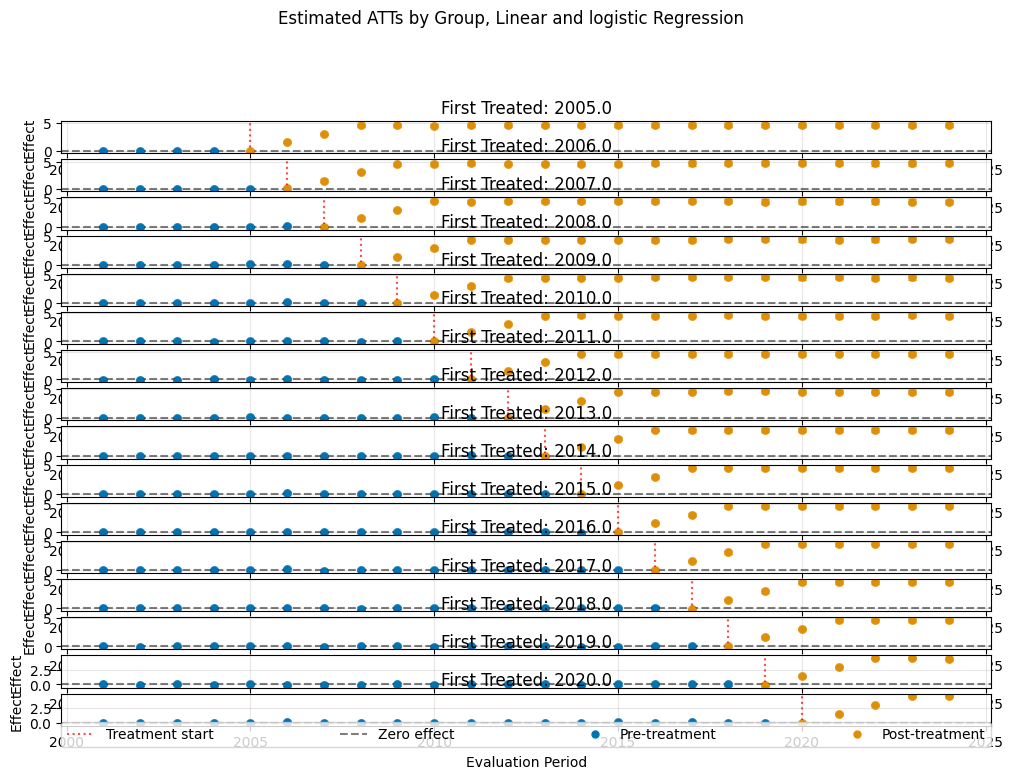

In [34]:
dml_obj_linear_logistic = DoubleMLDIDMulti(
    obj_dml_data=dml_data,
    ml_g=LinearRegression(),
    ml_m=LogisticRegression(penalty=None),
    control_group="never_treated",
    n_folds=10
)

dml_obj_linear_logistic.fit()
dml_obj_linear_logistic.bootstrap(n_rep_boot=5000)
dml_obj_linear_logistic.plot_effects(title="Estimated ATTs by Group, Linear and logistic Regression")

In [35]:
print(dml_obj_linear_logistic)

================== DoubleMLDIDMulti Object ==================

------------------ Data summary      ------------------
Outcome variable: Y
Treatment variable(s): ['treat_year']
Covariates: ['X1', 'X2', 'X3']
Instrument variable(s): None
Time variable: year
Id variable: codmun
No. Observations: 5573

------------------ Score & algorithm ------------------
Score function: observational
Control group: never_treated
Anticipation periods: 0

------------------ Machine learner   ------------------
Learner ml_g: LinearRegression()
Learner ml_m: LogisticRegression(penalty=None)
Out-of-sample Performance:
Regression:
Learner ml_g0 RMSE: [[0.42483308 0.41791037 0.42050359 0.42645314 0.49527541 0.5526081
  0.59712702 0.66010834 0.6817861  0.72467248 0.76735391 0.78827381
  0.82493535 0.85302677 0.89221577 0.92183813 0.93601825 0.95682732
  0.97765889 1.02187351 1.00726932 1.01037502 1.00907647 1.00416855
  0.42516622 0.41790151 0.42052858 0.42634665 0.49516031 0.49912393
  0.55466337 0.61571357 0

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Estimated ATTs by Group, Linear and logistic Regression'}, ylabel='Effect'>)

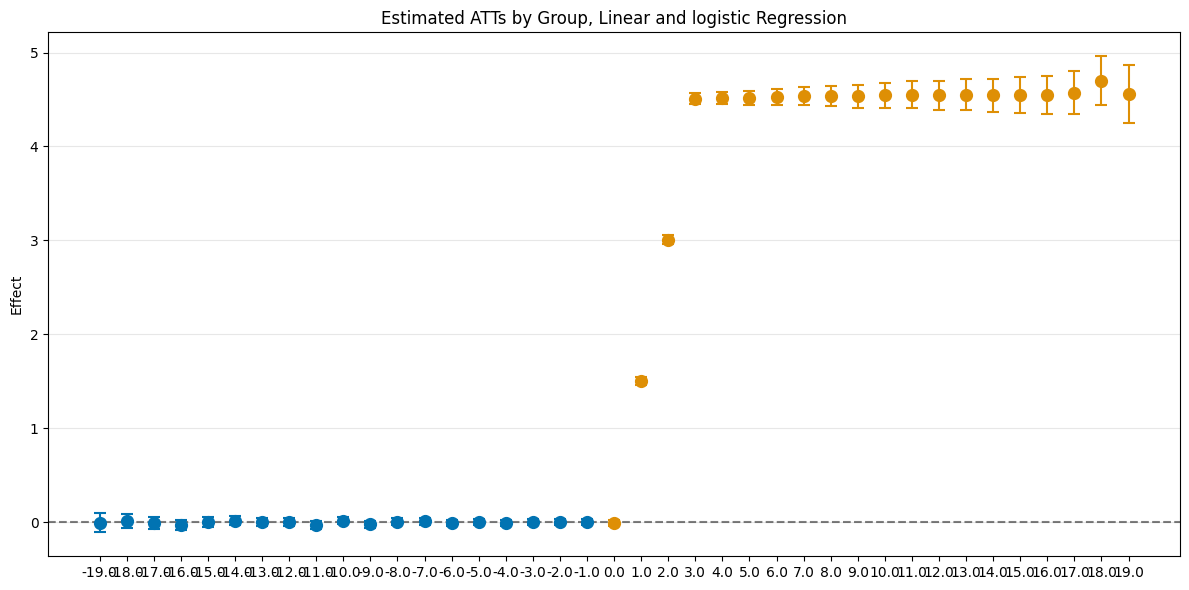

In [36]:
es_linear_logistic = dml_obj_linear_logistic.aggregate("eventstudy")
es_linear_logistic.aggregated_frameworks.bootstrap()
es_linear_logistic.plot_effects(title="Estimated ATTs by Group, Linear and logistic Regression")

(<Figure size 1200x800 with 17 Axes>,
 [<Axes: title={'center': 'First Treated: 2005.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2006.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2007.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2008.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2009.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2010.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2011.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2012.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2013.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2014.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2015.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2016.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2017.0'}, ylabel='Effect'>,
  <Axes: title={'center': 'First Treated: 2018.0'}, 

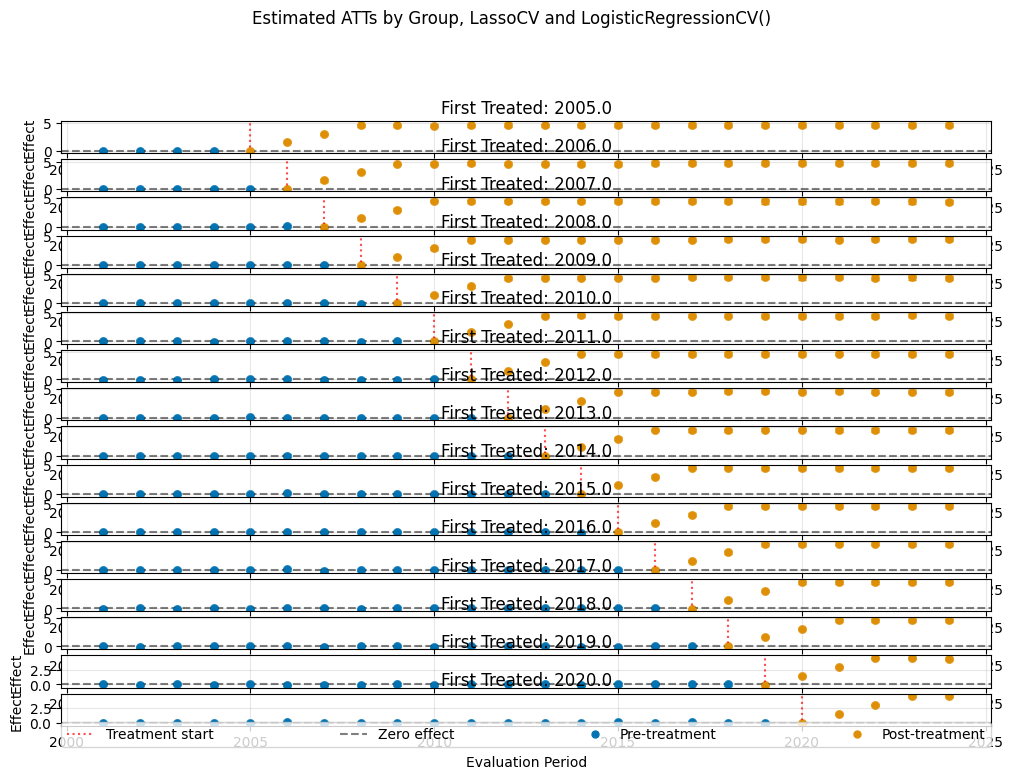

In [37]:
dml_obj_lasso = DoubleMLDIDMulti(
    obj_dml_data=dml_data,
    ml_g=LassoCV(),
    ml_m=LogisticRegressionCV(),
    control_group="never_treated",
    n_folds=10
)

dml_obj_lasso.fit()
dml_obj_lasso.bootstrap(n_rep_boot=5000)
dml_obj_lasso.plot_effects(title="Estimated ATTs by Group, LassoCV and LogisticRegressionCV()")

In [38]:
# Model summary
print(dml_obj_lasso)

================== DoubleMLDIDMulti Object ==================

------------------ Data summary      ------------------
Outcome variable: Y
Treatment variable(s): ['treat_year']
Covariates: ['X1', 'X2', 'X3']
Instrument variable(s): None
Time variable: year
Id variable: codmun
No. Observations: 5573

------------------ Score & algorithm ------------------
Score function: observational
Control group: never_treated
Anticipation periods: 0

------------------ Machine learner   ------------------
Learner ml_g: LassoCV()
Learner ml_m: LogisticRegressionCV()
Out-of-sample Performance:
Regression:
Learner ml_g0 RMSE: [[0.42446    0.4175359  0.42032397 0.42627319 0.49609952 0.55280643
  0.59676258 0.66020045 0.68172684 0.72551448 0.76728836 0.78854189
  0.82481607 0.85174565 0.89233017 0.92246955 0.93564956 0.95699657
  0.97743884 1.02210825 1.00698373 1.00972461 1.00795358 1.00349414
  0.4243572  0.41742668 0.42021043 0.42635127 0.49637469 0.49866183
  0.55563508 0.61592561 0.65126531 0.690512

(<Figure size 1200x600 with 1 Axes>,
 <Axes: title={'center': 'Estimated ATTs by Group, LassoCV and LogisticRegressionCV()'}, ylabel='Effect'>)

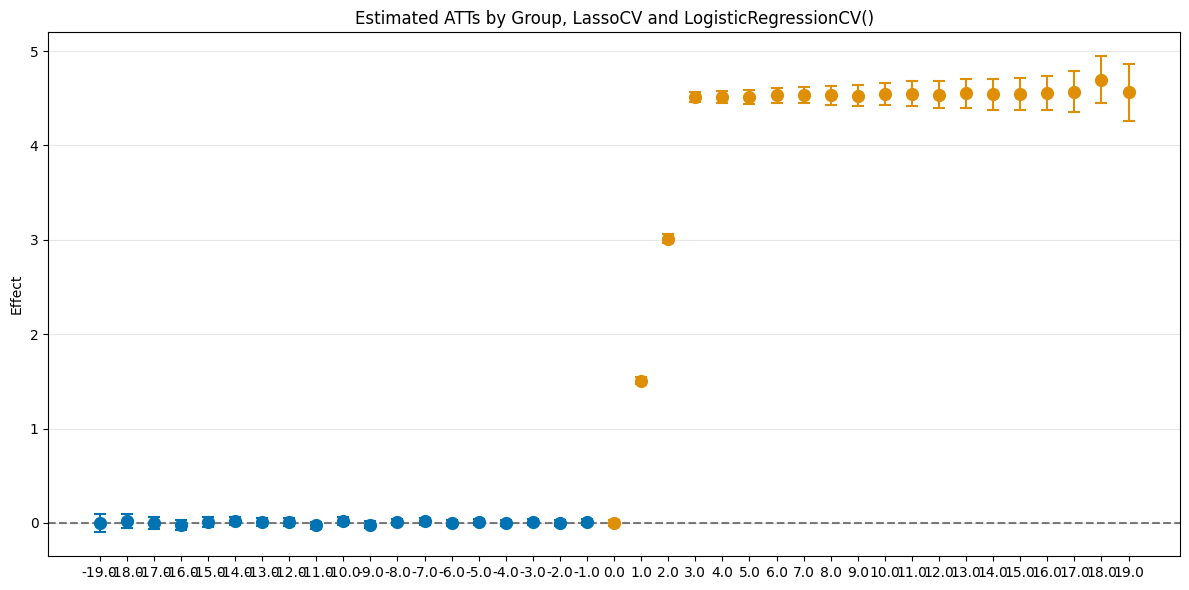

In [39]:
es_rf = dml_obj_lasso.aggregate("eventstudy")
es_rf.aggregated_frameworks.bootstrap()
es_rf.plot_effects(title="Estimated ATTs by Group, LassoCV and LogisticRegressionCV()")

Spatially-Disentangled Doubly Robust Machine Learning for Policy Evaluation

In [42]:
treated_munis = panel.loc[np.isfinite(panel['treat_year']), 'codmun'].unique()




In [43]:
neighbors_of_treated = set()
for m in treated_munis:
    neighbors_of_treated.update(w.neighbors.get(m, []))


In [44]:
panel['neighboard'] = panel['codmun'].isin(neighbors_of_treated).astype(int)


In [49]:
# Supondo que você já tenha: panel, gdf, e w = Queen.from_dataframe(gdf.set_index("codmun"))

# 1. Dicionário com ano de tratamento dos tratados
treated_year_dict = (
    panel.loc[np.isfinite(panel['treat_year']), ['codmun', 'treat_year']]
    .drop_duplicates()
    .set_index('codmun')['treat_year']
    .to_dict()
)

# 2. Criar dicionário com ano de spillover (menor ano de tratamento dos vizinhos)
spillover_treated_year = {}
for codmun in panel['codmun'].unique():
    neighbors = w.neighbors.get(codmun, [])
    neighbor_years = [treated_year_dict[n] for n in neighbors if n in treated_year_dict]
    if neighbor_years:
        spillover_treated_year[codmun] = min(neighbor_years)

# 3. Criar a nova variável
panel['SpilloverTreated'] = panel['codmun'].map(spillover_treated_year)



In [ ]:
panel 

,codmun,municipio,uf,X1,X2,X3,lat,lon,year,treat_year,...,years_treated,treatment_effect,X_index,spillover,alpha_i,lambda_t,epsilon,Y,neighboard,spill_year
0,3539400,Piratininga,SP,-0.026514,-0.564196,0.005205,-22.424953,-49.191797,2000,2005.0,...,0.0,0.0,0.742695,0.000000,74.14,0.00,-0.085463,75.813992,NaN,NaN
1,3152105,Ponte Nova,MG,0.781823,0.555941,0.925904,-20.412149,-42.917387,2000,2005.0,...,0.0,0.0,0.984692,0.000000,57.02,0.00,-0.284368,59.612283,NaN,NaN
2,3532843,Nova CanaÃ£ Paulista,SP,0.822060,0.098934,-0.848905,-20.372051,-50.910559,2000,2005.0,...,0.0,0.0,0.828676,0.000000,72.72,0.00,-0.018121,75.064908,NaN,NaN
3,3303955,Pinheiral,RJ,0.173181,-0.079908,-0.078331,-22.543326,-43.997547,2000,2005.0,...,0.0,0.0,0.799154,0.000000,64.60,0.00,-0.787445,65.868834,NaN,NaN
4,3305752,TanguÃ¡,RJ,0.216459,1.177185,0.975837,-22.782187,-42.725449,2000,2005.0,...,0.0,0.0,0.984674,0.000000,65.18,0.00,-0.390853,67.585063,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139320,1302801,MaraÃ£,AM,0.314087,0.603961,-0.508401,-2.426829,-65.039551,2024,inf,...,0.0,0.0,0.751355,3.756775,2.26,0.24,0.262679,8.096456,NaN,NaN
139321,1200450,Senador Guiomard,AC,-0.327298,-0.973198,0.975961,-9.997309,-67.427707,2024,inf,...,0.0,0.0,0.648213,1.944640,1.38,0.24,-0.312127,4.473119,NaN,NaN
139322,1303007,NhamundÃ¡,AM,0.174502,-0.895142,-0.671501,-1.680597,-57.656194,2024,inf,...,0.0,0.0,0.596245,1.788736,2.30,0.24,-0.472457,5.110876,NaN,NaN
139323,1301902,Itacoatiara,AM,1.399618,0.391093,0.555134,-3.174123,-58.775347,2024,inf,...,0.0,0.0,0.905098,4.525488,2.04,0.24,0.108983,9.116609,NaN,NaN


Efeito Direto Heterogêneo (ATT)
Estimativa do efeito do tratamento sobre os próprios tratados:

𝐴
𝑇
𝑇
𝑔
𝑡
=
𝐸
[
𝑌
𝑖
𝑡
(
1
)
−
𝑌
𝑖
𝑡
(
0
)
∣
𝐺
𝑖
=
𝑔
,
𝑇
=
𝑡
]
ATT 
gt
​
 =E[Y 
it
​
 (1)−Y 
it
​
 (0)∣G 
i
​
 =g,T=t]
A ser estimado com:

Callaway & Sant’Anna (2021) + DoubleML (para controle flexível)

Apenas municípios tratados diretamente

Comparados com nunca tratados ou ainda não tratados

Excluindo os vizinhos dos tratados para evitar contaminação por spillover

 Efeito Indireto Heterogêneo (Spillover)
Estimativa do efeito médio sobre municípios não tratados que são vizinhos de tratados:

𝐴
𝑇
𝑇
𝑔
𝑡
𝑠
𝑝
𝑖
𝑙
𝑙
𝑜
𝑣
𝑒
𝑟
=
𝐸
[
𝑌
𝑖
𝑡
∣
𝐷
𝑖
𝑡
=
0
,
𝑊
𝐷
𝑖
𝑡
>
0
]
−
𝐸
[
𝑌
𝑖
𝑡
∣
𝐷
𝑖
𝑡
=
0
,
𝑊
𝐷
𝑖
𝑡
=
0
]
ATT 
gt
spillover
​
 =E[Y 
it
​
 ∣D 
it
​
 =0,WD 
it
​
 >0]−E[Y 
it
​
 ∣D 
it
​
 =0,WD 
it
​
 =0]
A ser estimado com:

Diferença entre unidades não tratadas, comparando:

As que têm vizinhos tratados (W D_{it} > 0)

E as que não têm (W D_{it} = 0)

Também com controle via Machine Learning

Também com base em diferenças em diferenças (diferença relativa ao pré-tratamento)

#### Spatial Doubly Robust Machine Learning (SDRML)

Vamos tentar desagregar o efeito médio do tratamento em dois componentes:
- Efeito médio do tratamento heterogêneo direto

$$ ATT_{gt} = E[Y_{it} | D_{it} = 1] - E[Y_{it} | D_{it} = 0] $$

- Efeito médio do tratamento heterogêneo indireto (spillover)

$$ ATT_{gt}^{spillover} = E[Y_{it} | D_{it} = 0, W D_{it} > 0] - E[Y_{it} | D_{it} = 0, W D_{it} = 0] $$

A ideia é utilizar o estimador de Callaway e SantAnna com Double Machine Learning para estimar o efeito médio do tratamento heterogêneo direto (municípios tratados), excluindo os vizinhos dos tratados, e comparando-os com os nunca tratados ou ainda não tratados. Depois fazer a mesma coisa para o efeito médio do tratamento heterogêneo indireto (spillover), comparando-os com os nunca tratados ou ainda não tratados. Isso dentro do arcabouço de dupla robustez de Callaway e Sant'Anna (2021) e com a flexibilidade das funções do Machine Learning.



e indireto, considerando a vizinhança espacial.

In [53]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LassoCV, LogisticRegressionCV

from doubleml.data import DoubleMLPanelData
from doubleml.did import DoubleMLDIDMulti


In [73]:
# D = 1 se o município já foi tratado naquele ano ou depois, e 0 caso contrário
panel["D"] = ((panel["year"] >= panel["treat_year"]) & (panel["treat_year"] > 0)).astype(int)


In [74]:
from doubleml.data import DoubleMLPanelData
from doubleml.did import DoubleMLDID
from sklearn.linear_model import LassoCV, LogisticRegressionCV

# Criar o objeto DoubleMLPanelData com a base limpa e corrigida
data_dml = DoubleMLPanelData(
    data=panel,
    y_col='Y',
    d_cols='D',
    x_cols=['X1', 'X2', 'X3'],
    t_col='year',
    id_col='codmun'
)

# Instanciar e ajustar o estimador
dml_did = DoubleMLDID(
    data_dml,
    ml_g=LassoCV(cv=5),
    ml_m=LogisticRegressionCV(cv=5, max_iter=1000),
    score='observational'
)

dml_did.fit()

# Ver resultado
print(dml_did.summary)



ValueError: Found input variables with inconsistent numbers of samples: [5573, 139325]

In [68]:
from doubleml.data import DoubleMLPanelData
from doubleml.did import DoubleMLDIDCS
from sklearn.linear_model import LassoCV, LogisticRegressionCV

# Garantir que o tempo seja inteiro
panel['year'] = panel['year'].astype(int)

# Criar o objeto DoubleMLPanelData
data = DoubleMLPanelData(
    data=panel,
    y_col='Y',
    d_cols='D',
    x_cols=['X1', 'X2', 'X3'],
    t_col='year',
    id_col='codmun'
)

# Instanciar corretamente o estimador (sem nomes nos argumentos)
dml_did_cs = DoubleMLDIDCS(
    data,
    LassoCV(cv=5),
    LogisticRegressionCV(cv=5, max_iter=1000),
    score='observational'
)

# Estimar
dml_did_cs.fit()

# Resultado
print(dml_did_cs.summary)


ValueError: Incompatible data. To fit an DIDCS model with DML exactly one binary variable with values 0 and 1 needs to be specified as time variable.

In [67]:
from doubleml.data import DoubleMLPanelData
from doubleml.did import DoubleMLDIDCS
from sklearn.linear_model import LassoCV, LogisticRegressionCV

# 1. Carregando os dados simulados (ajustar nomes se necessário)
panel['year'] = panel['year'].astype(int)

# 2. Criar objeto DoubleMLPanelData corretamente
# Aqui você já passa todas as variáveis necessárias
data = DoubleMLPanelData(
    data=panel,
    y_col='Y',         # variável dependente
    d_cols='D',         # tratamento (1 tratado, 0 não tratado)
    x_cols=['X1', 'X2', 'X3'],  # covariáveis
    t_col='year',      # variável de tempo
    id_col='codmun'  # identificador do painel
)

# 3. Instanciar o estimador corretamente, sem repetir y_col etc.
dml_did_cs = DoubleMLDIDCS(
    data=data,
    ml_g=LassoCV(cv=5),
    ml_m=LogisticRegressionCV(cv=5, max_iter=1000),
    score='observational'  # ou 'ATE' se preferir
)

# 4. Rodar a estimação
dml_did_cs.fit()

# 5. Ver resultados
print(dml_did_cs.summary)


TypeError: DoubleMLDIDCS.__init__() got an unexpected keyword argument 'data'

In [ ]:
import numpy as np
import pandas as pd

from sklearn.linear_model import LassoCV, LogisticRegressionCV
from doubleml.data import DoubleMLPanelData
from doubleml.did import DoubleMLDIDCS

# 2. Garante que 'year' é inteiro
panel['year'] = panel['year'].astype(int)

# 3. Criação do objeto DoubleMLPanelData (seguindo o exemplo do site)
data = DoubleMLPanelData(
    data=panel,
    t_col='year',
    id_col='codmun',
    y_col='Y',
    d_cols='D',
    x_cols=['X1', 'X2', 'X3'],
)

# 4. Instancia o estimador DoubleMLDIDCS (Cross-Section DiD)
dml_did_cs = DoubleMLDIDCS(
    data,
    y_col='Y',
    d_col='D',
    x_cols=['X1', 'X2', 'X3'],
    ml_g=LassoCV(cv=5),
    ml_m=LogisticRegressionCV(cv=5, max_iter=1000),
    score='observational'
)

# 5. Estima o modelo
dml_did_cs.fit()

# 6. Resultado
print(dml_did_cs.summary)



TypeError: DoubleMLDIDCS.__init__() got an unexpected keyword argument 'y_col'

In [54]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LassoCV, LogisticRegressionCV
from doubleml.data import DoubleMLPanelData
from doubleml.did import DoubleMLDIDMulti

# --------------------------------------------------
# 1. Preparar os dados
# --------------------------------------------------
# Certifique-se de que 'codmun' e 'year' sejam do tipo adequado
panel['codmun'] = panel['codmun'].astype(str)
panel['year'] = panel['year'].astype(int)

# --------------------------------------------------
# 2. Criar objeto DoubleMLPanelData
# --------------------------------------------------
dml_data = DoubleMLPanelData(
    data=panel,
    y_col='Y',
    d_col='D',
    x_cols=['X1', 'X2', 'X3'],
    time_col='year',
    cluster_cols='codmun',
    unit_col='codmun'
)

# --------------------------------------------------
# 3. Estimador DoubleMLDIDMulti (DID com várias coortes)
# --------------------------------------------------
dml_did = DoubleMLDIDMulti(
    data=dml_data,
    ml_g=LassoCV(cv=5),
    ml_m=LogisticRegressionCV(cv=5, max_iter=1000),
    score='observational'
)

# --------------------------------------------------
# 4. Ajustar o modelo
# --------------------------------------------------
dml_did.fit()

# --------------------------------------------------
# 5. Ver resultados
# --------------------------------------------------
print(dml_did.summary)


TypeError: DoubleMLPanelData.__init__() got an unexpected keyword argument 'd_col'

In [ ]:
from doubleml import DoubleMLPanelData


dml_data = DoubleMLPanelData(
    data=panel,
    y_col="Y",
    d_cols="D",            # sua variável de tratamento (0/1)
    id_col="codmun",
    t_col="year",
    x_cols=["X1", "X2", "X3"]  # covariáveis preditoras
)

ImportError: cannot import name 'DoubleMLPanelData' from 'doubleml' (c:\Users\danie\AppData\Local\Programs\Python\Python310\lib\site-packages\doubleml\__init__.py)

In [48]:
import doubleml as dml
print(dml.__version__)


0.10.0


### Estimador para Callaway e Sant'Anna (2021)

**ideia geral**

A ideia aqui é partir do estimador de Sant'Anna e Zhao (2020) e adaptá-lo para o caso de múltiplos períodos de tratamento, como proposto por Callaway e Sant'Anna (2021). Vamos utilizar o pacote em python do DoubleML para implementar o estimador. E compará-lo com o estimador `differences` do python.

**Objetivo do Projeto**

* Implementar o estimador de Callaway & Sant’Anna (2021) para múltiplos períodos de tratamento, adaptando o DoubleML (que já possui o estimador de Sant'Anna & Zhao, 2020).
* Comparar os resultados com o estimador differences disponível no Python.
* Analisar consistência, precisão, robustez e desempenho computacional dos dois 


!pip install differences
!pip install doubleml

In [3]:
import pandas as pd
import numpy as np

data = pd.read_stata("https://github.com/Daniel-Uhr/data/raw/main/bacon_example.dta")

In [4]:
# Filtragem dos dados
# Vamos criar identificadores estaduais
data['id'] = data['stfips'].rank(method='dense').astype(int)

# time to treat
data['t'] = data['year'] - data['_nfd']

# Outcome (Suicide Mortality)
data['y'] = data['asmrs']

# Covariáveis - pcinc asmrh cases
data['X1'] = data['pcinc']
data['X2'] = data['asmrh']
data['X3'] = data['cases']

# Treatment
data['D'] = data['post']
data['media_D'] = data.groupby('id')['D'].transform('mean')
data['always_treated'] = np.where(data['media_D'] == 1, 1, 0)
data['never_treated'] = np.where(data['media_D'] == 0, 1, 0)
# foi tratado em algum momento media_D for maior que 0, será um valor 1 para o id
data['treated'] = np.where(data['media_D'] > 0, 1, 0)

# Vamos criar a variável de grupo G
data['cohort']=data['_nfd']

In [ ]:
print(sorted(data['t'].unique()))

[-21.0, -20.0, -19.0, -18.0, -17.0, -16.0, -15.0, -14.0, -13.0, -12.0, -11.0, -10.0, -9.0, -8.0, -7.0, -6.0, -5.0, -4.0, -3.0, -2.0, -1.0, 0.0, 1.0, 2.0, 3.0, 4.0, 5.0, 6.0, 7.0, 8.0, 9.0, 10.0, 11.0, 12.0, 13.0, 14.0, 15.0, 16.0, 17.0, 18.0, 19.0, 20.0, 21.0, 22.0, 23.0, 24.0, 25.0, nan, 26.0, 27.0]


In [6]:
data

,stfips,year,_nfd,post,asmrs,pcinc,asmrh,cases,weight,copop,...,y,X1,X2,X3,D,media_D,always_treated,never_treated,treated,cohort
0,1,1964.0,1971.0,0.0,35.639885,12406.178537,5.007341,0.012312,1.715156e+06,1.715156e+06,...,35.639885,12406.178537,5.007341,0.012312,0.0,0.787879,0,0,1,1971.0
1,1,1965.0,1971.0,0.0,41.543755,13070.206738,4.425367,0.010419,1.715156e+06,1.725186e+06,...,41.543755,13070.206738,4.425367,0.010419,0.0,0.787879,0,0,1,1971.0
2,1,1966.0,1971.0,0.0,34.252335,13526.663217,4.874819,0.009900,1.715156e+06,1.735219e+06,...,34.252335,13526.663217,4.874819,0.009900,0.0,0.787879,0,0,1,1971.0
3,1,1967.0,1971.0,0.0,34.465023,13918.189823,5.362014,0.009975,1.715156e+06,1.745250e+06,...,34.465023,13918.189823,5.362014,0.009975,0.0,0.787879,0,0,1,1971.0
4,1,1968.0,1971.0,0.0,40.440105,14684.808682,4.643759,0.012401,1.715156e+06,1.755283e+06,...,40.440105,14684.808682,4.643759,0.012401,0.0,0.787879,0,0,1,1971.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1612,56,1992.0,1977.0,1.0,33.149574,31181.450546,1.970134,0.028996,1.621688e+05,2.323830e+05,...,33.149574,31181.450546,1.970134,0.028996,1.0,0.606061,0,0,1,1977.0
1613,56,1993.0,1977.0,1.0,63.909775,31666.776231,3.020953,0.026672,1.621688e+05,2.355600e+05,...,63.909775,31666.776231,3.020953,0.026672,1.0,0.606061,0,0,1,1977.0
1614,56,1994.0,1977.0,1.0,81.793816,31959.528356,3.501871,0.023643,1.621688e+05,2.389800e+05,...,81.793816,31959.528356,3.501871,0.023643,1.0,0.606061,0,0,1,1977.0
1615,56,1995.0,1977.0,1.0,30.630585,32327.659531,0.740606,0.020965,1.621688e+05,2.414090e+05,...,30.630585,32327.659531,0.740606,0.020965,1.0,0.606061,0,0,1,1977.0


In [7]:
data['cohort'].describe()

count    1188.000000
mean     1973.583333
std         3.539969
min      1969.000000
25%      1971.000000
50%      1973.000000
75%      1974.250000
max      1985.000000
Name: cohort, dtype: float64

In [8]:
# Criar uma base de dados com apenas um grupo tratado específico e todos os nunca tratados.
data_sz = data[(data['cohort'] == 1973) | (data['never_treated'] == 1)]

In [9]:
data_sz

,stfips,year,_nfd,post,asmrs,pcinc,asmrh,cases,weight,copop,...,y,X1,X2,X3,D,media_D,always_treated,never_treated,treated,cohort
33,4,1964.0,1973.0,0.0,73.528717,15551.315938,3.083218,0.012883,744813.0,7.448130e+05,...,73.528717,15551.315938,3.083218,0.012883,0.0,0.727273,0,0,1,1973.0
34,4,1965.0,1973.0,0.0,82.431198,15962.689260,3.005868,0.012225,744813.0,7.692093e+05,...,82.431198,15962.689260,3.005868,0.012225,0.0,0.727273,0,0,1,1973.0
35,4,1966.0,1973.0,0.0,59.255363,16581.270102,5.074290,0.012180,744813.0,7.936050e+05,...,59.255363,16581.270102,5.074290,0.012180,0.0,0.727273,0,0,1,1973.0
36,4,1967.0,1973.0,0.0,81.493416,17214.603202,3.836898,0.012327,744813.0,8.180007e+05,...,81.493416,17214.603202,3.836898,0.012327,0.0,0.727273,0,0,1,1973.0
37,4,1968.0,1973.0,0.0,72.936737,18610.393366,5.394385,0.012178,744813.0,8.423957e+05,...,72.936737,18610.393366,5.394385,0.012178,0.0,0.727273,0,0,1,1973.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1513,53,1992.0,1973.0,1.0,50.471672,35482.948403,3.107361,0.037566,1546064.0,2.598309e+06,...,50.471672,35482.948403,3.107361,0.037566,1.0,0.727273,0,0,1,1973.0
1514,53,1993.0,1973.0,1.0,47.067001,35571.542235,2.844220,0.038398,1546064.0,2.656901e+06,...,47.067001,35571.542235,2.844220,0.038398,1.0,0.727273,0,0,1,1973.0
1515,53,1994.0,1973.0,1.0,45.564236,35987.602571,3.035455,0.038123,1546064.0,2.705420e+06,...,45.564236,35987.602571,3.035455,0.038123,1.0,0.727273,0,0,1,1973.0
1516,53,1995.0,1973.0,1.0,45.268627,36422.286961,3.326494,0.036635,1546064.0,2.756447e+06,...,45.268627,36422.286961,3.326494,0.036635,1.0,0.727273,0,0,1,1973.0


#### Aplicar DoubleML-DID



Analisar a dupla diferença para os períodos t=-1 e t=1.

In [11]:
# 1. Manter na base apenas t == -1, t == 1 ou t == NA
data_sz_1 = data_sz[(data_sz['t'].isin([-1.0, 1.0])) | (data_sz['t'].isna())]

# 2. Identificar anos dos tratados
anos_tratados = data_sz_1[data_sz_1['never_treated'] == 0]['year'].unique()

# 3. Filtrar: manter tratados ou never_treated com anos dos tratados
data_sz_1 = data_sz_1[(data_sz_1['never_treated'] == 0) | ((data_sz_1['never_treated'] == 1) & (data_sz_1['year'].isin(anos_tratados)))]
data_sz_1

,stfips,year,_nfd,post,asmrs,pcinc,asmrh,cases,weight,copop,...,y,X1,X2,X3,D,media_D,always_treated,never_treated,treated,cohort
41,4,1972.0,1973.0,0.0,101.922516,22979.025315,3.912483,0.018428,7.448130e+05,1017302.0,...,101.922516,22979.025315,3.912483,0.018428,0.0,0.727273,0,0,1,1973.0
43,4,1974.0,1973.0,1.0,87.002365,23114.632475,4.767786,0.018148,7.448130e+05,1125678.0,...,87.002365,23114.632475,4.767786,0.018148,1.0,0.727273,0,0,1,1973.0
74,5,1972.0,NaN,0.0,56.250359,17225.678238,4.724695,0.020913,9.379597e+05,1038165.0,...,56.250359,17225.678238,4.724695,0.020913,0.0,0.000000,0,1,0,NaN
76,5,1974.0,NaN,0.0,48.406815,18717.644793,4.108365,0.026070,9.379597e+05,1080970.0,...,48.406815,18717.644793,4.108365,0.026070,0.0,0.000000,0,1,0,NaN
173,9,1972.0,1973.0,0.0,47.559387,28467.286435,1.722194,0.020316,1.407318e+06,1580484.0,...,47.559387,28467.286435,1.722194,0.020316,0.0,0.727273,0,0,1,1973.0
175,9,1974.0,1973.0,1.0,38.020470,28855.494139,2.411515,0.023150,1.407318e+06,1586262.0,...,38.020470,28855.494139,2.411515,0.023150,1.0,0.727273,0,0,1,1973.0
206,10,1972.0,NaN,0.0,47.521610,26803.135702,1.417574,0.030777,2.475022e+05,294246.0,...,47.521610,26803.135702,1.417574,0.030777,0.0,0.000000,0,1,0,NaN
208,10,1974.0,NaN,0.0,56.700481,27049.663476,5.338567,0.030429,2.475022e+05,299688.0,...,56.700481,27049.663476,5.338567,0.030429,0.0,0.000000,0,1,0,NaN
305,13,1972.0,1973.0,0.0,67.377106,20588.342698,7.584846,0.038746,2.150928e+06,2476205.0,...,67.377106,20588.342698,7.584846,0.038746,0.0,0.727273,0,0,1,1973.0
307,13,1974.0,1973.0,1.0,64.986893,21006.430168,9.746268,0.041766,2.150928e+06,2576772.0,...,64.986893,21006.430168,9.746268,0.041766,1.0,0.727273,0,0,1,1973.0


Fazer o procedimento para utilizar o DML

In [12]:
# criar uma variável de diferença de y na base data_sz_1['y_diff'] 
data_sz_1['y_diff'] = data_sz_1.groupby('id')['y'].diff()

# substituir valores data_sz_1['y_diff'] "na" pelo valor da y_diff do id calculado para o período posterior
data_sz_1['y_diff'] = data_sz_1.groupby('id')['y_diff'].fillna(method='bfill')


C:\Users\danie\AppData\Local\Temp\ipykernel_15180\1607195728.py:5: FutureWarning: SeriesGroupBy.fillna is deprecated and will be removed in a future version. Use obj.ffill() or obj.bfill() for forward or backward filling instead. If you want to fill with a single value, use Series.fillna instead
  data_sz_1['y_diff'] = data_sz_1.groupby('id')['y_diff'].fillna(method='bfill')
C:\Users\danie\AppData\Local\Temp\ipykernel_15180\1607195728.py:5: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data_sz_1['y_diff'] = data_sz_1.groupby('id')['y_diff'].fillna(method='bfill')


In [13]:
data_sz_1

,stfips,year,_nfd,post,asmrs,pcinc,asmrh,cases,weight,copop,...,X1,X2,X3,D,media_D,always_treated,never_treated,treated,cohort,y_diff
41,4,1972.0,1973.0,0.0,101.922516,22979.025315,3.912483,0.018428,7.448130e+05,1017302.0,...,22979.025315,3.912483,0.018428,0.0,0.727273,0,0,1,1973.0,-14.920151
43,4,1974.0,1973.0,1.0,87.002365,23114.632475,4.767786,0.018148,7.448130e+05,1125678.0,...,23114.632475,4.767786,0.018148,1.0,0.727273,0,0,1,1973.0,-14.920151
74,5,1972.0,NaN,0.0,56.250359,17225.678238,4.724695,0.020913,9.379597e+05,1038165.0,...,17225.678238,4.724695,0.020913,0.0,0.000000,0,1,0,NaN,-7.843544
76,5,1974.0,NaN,0.0,48.406815,18717.644793,4.108365,0.026070,9.379597e+05,1080970.0,...,18717.644793,4.108365,0.026070,0.0,0.000000,0,1,0,NaN,-7.843544
173,9,1972.0,1973.0,0.0,47.559387,28467.286435,1.722194,0.020316,1.407318e+06,1580484.0,...,28467.286435,1.722194,0.020316,0.0,0.727273,0,0,1,1973.0,-9.538918
175,9,1974.0,1973.0,1.0,38.020470,28855.494139,2.411515,0.023150,1.407318e+06,1586262.0,...,28855.494139,2.411515,0.023150,1.0,0.727273,0,0,1,1973.0,-9.538918
206,10,1972.0,NaN,0.0,47.521610,26803.135702,1.417574,0.030777,2.475022e+05,294246.0,...,26803.135702,1.417574,0.030777,0.0,0.000000,0,1,0,NaN,9.178871
208,10,1974.0,NaN,0.0,56.700481,27049.663476,5.338567,0.030429,2.475022e+05,299688.0,...,27049.663476,5.338567,0.030429,0.0,0.000000,0,1,0,NaN,9.178871
305,13,1972.0,1973.0,0.0,67.377106,20588.342698,7.584846,0.038746,2.150928e+06,2476205.0,...,20588.342698,7.584846,0.038746,0.0,0.727273,0,0,1,1973.0,-2.390213
307,13,1974.0,1973.0,1.0,64.986893,21006.430168,9.746268,0.041766,2.150928e+06,2576772.0,...,21006.430168,9.746268,0.041766,1.0,0.727273,0,0,1,1973.0,-2.390213


In [14]:
df_dml = data_sz_1[data_sz_1['year'] == data_sz_1['year'].min()].copy()
df_dml

,stfips,year,_nfd,post,asmrs,pcinc,asmrh,cases,weight,copop,...,X1,X2,X3,D,media_D,always_treated,never_treated,treated,cohort,y_diff
41,4,1972.0,1973.0,0.0,101.922516,22979.025315,3.912483,0.018428,7.448130e+05,1017302.0,...,22979.025315,3.912483,0.018428,0.0,0.727273,0,0,1,1973.0,-14.920151
74,5,1972.0,NaN,0.0,56.250359,17225.678238,4.724695,0.020913,9.379597e+05,1038165.0,...,17225.678238,4.724695,0.020913,0.0,0.000000,0,1,0,NaN,-7.843544
173,9,1972.0,1973.0,0.0,47.559387,28467.286435,1.722194,0.020316,1.407318e+06,1580484.0,...,28467.286435,1.722194,0.020316,0.0,0.727273,0,0,1,1973.0,-9.538918
206,10,1972.0,NaN,0.0,47.521610,26803.135702,1.417574,0.030777,2.475022e+05,294246.0,...,26803.135702,1.417574,0.030777,0.0,0.000000,0,1,0,NaN,9.178871
305,13,1972.0,1973.0,0.0,67.377106,20588.342698,7.584846,0.038746,2.150928e+06,2476205.0,...,20588.342698,7.584846,0.038746,0.0,0.727273,0,0,1,1973.0,-2.390213
404,18,1972.0,1973.0,0.0,56.968685,22011.952470,2.517947,0.017422,2.490114e+06,2711777.0,...,22011.952470,2.517947,0.017422,0.0,0.727273,0,0,1,1973.0,-5.073200
569,23,1972.0,1973.0,0.0,46.754639,19694.904842,3.060293,0.034757,4.958082e+05,529513.0,...,19694.904842,3.060293,0.034757,0.0,0.727273,0,0,1,1973.0,16.283157
734,28,1972.0,NaN,0.0,43.245850,16283.150389,6.472214,0.037212,1.118302e+06,1186875.0,...,16283.150389,6.472214,0.037212,0.0,0.000000,0,1,0,NaN,0.141403
767,29,1972.0,1973.0,0.0,58.237740,22350.673416,3.024333,0.026119,2.298065e+06,2459347.0,...,22350.673416,3.024333,0.026119,0.0,0.727273,0,0,1,1973.0,1.111126
866,32,1972.0,1973.0,0.0,111.368187,28388.742447,5.085210,0.017197,1.795353e+05,269158.0,...,28388.742447,5.085210,0.017197,0.0,0.727273,0,0,1,1973.0,49.472572


In [71]:
from sklearn.linear_model import LinearRegression, LogisticRegression
from doubleml import DoubleMLDID
import numpy as np
from doubleml import DoubleMLData

np.random.seed(1)

dml_data = DoubleMLData.from_arrays(
    x= df_dml[['X1', 'X2', 'X3']],
    y=df_dml['y_diff'],
    d=df_dml['treated']
)

ml_g = LinearRegression()
ml_m = LogisticRegression()

dml_did1 = DoubleMLDID(
    dml_data,
    ml_g=ml_g,
    ml_m=ml_m,
    score='observational',
    n_folds=2
)

dml_did1.fit()
print(dml_did1.summary)
print("Intervalo de confiança 95%:")
print(dml_did1.confint(level=0.95))


       coef    std err         t     P>|t|      2.5 %     97.5 %
d  4.522434  21.074514  0.214593  0.830085 -36.782854  45.827722
Intervalo de confiança 95%:
       2.5 %     97.5 %
d -36.782854  45.827722


c:\Users\danie\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [82]:
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from doubleml import DoubleMLDID
import numpy as np
from doubleml import DoubleMLData

np.random.seed(1)

dml_data = DoubleMLData.from_arrays(
    x= df_dml[['X1', 'X2', 'X3']],
    y=df_dml['y_diff'],
    d=df_dml['treated']
)

ml_g = RandomForestRegressor()
ml_m = RandomForestClassifier()

dml_did2 = DoubleMLDID(
    dml_data,
    ml_g=ml_g,
    ml_m=ml_m,
    score='observational',
    n_folds=2
)

dml_did2.fit()
print(dml_did2.summary)
print("Intervalo de confiança 95%:")
print(dml_did2.confint(level=0.95))

       coef   std err         t     P>|t|      2.5 %     97.5 %
d -1.959208  7.337674 -0.267007  0.789464 -16.340785  12.422369
Intervalo de confiança 95%:
       2.5 %     97.5 %
d -16.340785  12.422369


In [83]:
data_sz_1

stfips    year    _nfd  post       asmrs         pcinc     asmrh  \
id1 year1                                                                     
2   1972        4  1972.0  1973.0   0.0  101.922516  22979.025315  3.912483   
    1974        4  1974.0  1973.0   1.0   87.002365  23114.632475  4.767786   
3   1972        5  1972.0     NaN   0.0   56.250359  17225.678238  4.724695   
    1974        5  1974.0     NaN   0.0   48.406815  18717.644793  4.108365   
6   1972        9  1972.0  1973.0   0.0   47.559387  28467.286435  1.722194   
    1974        9  1974.0  1973.0   1.0   38.020470  28855.494139  2.411515   
7   1972       10  1972.0     NaN   0.0   47.521610  26803.135702  1.417574   
    1974       10  1974.0     NaN   0.0   56.700481  27049.663476  5.338567   
10  1972       13  1972.0  1973.0   0.0   67.377106  20588.342698  7.584846   
    1974       13  1974.0  1973.0   1.0   64.986893  21006.430168  9.746268   
13  1972       18  1972.0  1973.0   0.0   56.968685  22011.952470  2.517947   
    1974       18  1974.0  1973.0   1.0   51.895485  22875.254923  3.930914   
18  1972       23  1972.0  1973.0   0.0   46.754639  19694.904842  3.060293   
    1974       23  1974.0  1973.0   1.0   63.037796  20510.876637  2.174452   
23  1972       28  1972.0     NaN   0.0   43.245850  16283.150389  6.472214   
    1974       28  1974.0     NaN   0.0   43.387253  16966.409012  6.367793   
24  1972       29  1972.0  1973.0   0.0   58.237740  22350.673416  3.024333   
    1974       29  1974.0  1973.0   1.0   59.348866  22577.082883  2.947727   
27  1972       32  1972.0  1973.0   0.0  111.368187  28388.742447  5.085210   
    1974       32  1974.0  1973.0   1.0  160.840759  27944.179595  8.146376   
30  1972       35  1972.0  1973.0   0.0   51.931870  19685.086843  5.733760   
    1974       35  1974.0  1973.0   1.0   69.617287  20216.904204  3.798809   
31  1972       36  1972.0     NaN   0.0   37.546421  27583.666577  3.493527   
    1974       36  1974.0     NaN   0.0   35.241112  27436.027246  3.842149   
36  1972       41  1972.0  1973.0   0.0   84.219421  23327.564259  2.915845   
    1974       41  1974.0  1973.0   1.0   75.755478  24529.899762  2.952571   
41  1972       47  1972.0     NaN   0.0   50.976021  19164.732927  5.394639   
    1974       47  1974.0     NaN   0.0   59.248425  20036.321137  4.638008   
46  1972       53  1972.0  1973.0   0.0   84.728195  24196.457120  1.711642   
    1974       53  1974.0  1973.0   1.0   82.237000  25684.791464  2.639225   

              cases        weight      copop  ...            X1        X2  \
id1 year1                                     ...                           
2   1972   0.018428  7.448130e+05  1017302.0  ...  22979.025315  3.912483   
    1974   0.018148  7.448130e+05  1125678.0  ...  23114.632475  4.767786   
3   1972   0.020913  9.379597e+05  1038165.0  ...  17225.678238  4.724695   
    1974   0.026070  9.379597e+05  1080970.0  ...  18717.644793  4.108365   
6   1972   0.020316  1.407318e+06  1580484.0  ...  28467.286435  1.722194   
    1974   0.023150  1.407318e+06  1586262.0  ...  28855.494139  2.411515   
7   1972   0.030777  2.475022e+05   294246.0  ...  26803.135702  1.417574   
    1974   0.030429  2.475022e+05   299688.0  ...  27049.663476  5.338567   
10  1972   0.038746  2.150928e+06  2476205.0  ...  20588.342698  7.584846   
    1974   0.041766  2.150928e+06  2576772.0  ...  21006.430168  9.746268   
13  1972   0.017422  2.490114e+06  2711777.0  ...  22011.952470  2.517947   
    1974   0.018639  2.490114e+06  2741821.0  ...  22875.254923  3.930914   
18  1972   0.034757  4.958082e+05   529513.0  ...  19694.904842  3.060293   
    1974   0.041076  4.958082e+05   543179.0  ...  20510.876637  2.174452   
23  1972   0.037212  1.118302e+06  1186875.0  ...  16283.150389  6.472214   
    1974   0.042730  1.118302e+06  1225186.0  ...  16966.409012  6.367793   
24  1972   0.026119  2.298065e+06  2459347.0  ...  22350.673416  3.024333   
    1974   0.031987

In [73]:
# O pacote precisa entender a estrutura de painel dos dados. Precisamos ajustar a variável year para int (inteiro)
# Criando clones
data_sz_1['year1'] = data_sz_1['year']
data_sz_1['id1'] = data_sz_1['id']
data_sz_1['year1'] = data_sz_1['year'].astype(int)


data_sz_1.set_index(['id1', 'year1'], inplace=True)


data_sz_1

stfips    year    _nfd  post       asmrs         pcinc     asmrh  \
id1 year1                                                                     
2   1972        4  1972.0  1973.0   0.0  101.922516  22979.025315  3.912483   
    1974        4  1974.0  1973.0   1.0   87.002365  23114.632475  4.767786   
3   1972        5  1972.0     NaN   0.0   56.250359  17225.678238  4.724695   
    1974        5  1974.0     NaN   0.0   48.406815  18717.644793  4.108365   
6   1972        9  1972.0  1973.0   0.0   47.559387  28467.286435  1.722194   
    1974        9  1974.0  1973.0   1.0   38.020470  28855.494139  2.411515   
7   1972       10  1972.0     NaN   0.0   47.521610  26803.135702  1.417574   
    1974       10  1974.0     NaN   0.0   56.700481  27049.663476  5.338567   
10  1972       13  1972.0  1973.0   0.0   67.377106  20588.342698  7.584846   
    1974       13  1974.0  1973.0   1.0   64.986893  21006.430168  9.746268   
13  1972       18  1972.0  1973.0   0.0   56.968685  22011.952470  2.517947   
    1974       18  1974.0  1973.0   1.0   51.895485  22875.254923  3.930914   
18  1972       23  1972.0  1973.0   0.0   46.754639  19694.904842  3.060293   
    1974       23  1974.0  1973.0   1.0   63.037796  20510.876637  2.174452   
23  1972       28  1972.0     NaN   0.0   43.245850  16283.150389  6.472214   
    1974       28  1974.0     NaN   0.0   43.387253  16966.409012  6.367793   
24  1972       29  1972.0  1973.0   0.0   58.237740  22350.673416  3.024333   
    1974       29  1974.0  1973.0   1.0   59.348866  22577.082883  2.947727   
27  1972       32  1972.0  1973.0   0.0  111.368187  28388.742447  5.085210   
    1974       32  1974.0  1973.0   1.0  160.840759  27944.179595  8.146376   
30  1972       35  1972.0  1973.0   0.0   51.931870  19685.086843  5.733760   
    1974       35  1974.0  1973.0   1.0   69.617287  20216.904204  3.798809   
31  1972       36  1972.0     NaN   0.0   37.546421  27583.666577  3.493527   
    1974       36  1974.0     NaN   0.0   35.241112  27436.027246  3.842149   
36  1972       41  1972.0  1973.0   0.0   84.219421  23327.564259  2.915845   
    1974       41  1974.0  1973.0   1.0   75.755478  24529.899762  2.952571   
41  1972       47  1972.0     NaN   0.0   50.976021  19164.732927  5.394639   
    1974       47  1974.0     NaN   0.0   59.248425  20036.321137  4.638008   
46  1972       53  1972.0  1973.0   0.0   84.728195  24196.457120  1.711642   
    1974       53  1974.0  1973.0   1.0   82.237000  25684.791464  2.639225   

              cases        weight      copop  ...            X1        X2  \
id1 year1                                     ...                           
2   1972   0.018428  7.448130e+05  1017302.0  ...  22979.025315  3.912483   
    1974   0.018148  7.448130e+05  1125678.0  ...  23114.632475  4.767786   
3   1972   0.020913  9.379597e+05  1038165.0  ...  17225.678238  4.724695   
    1974   0.026070  9.379597e+05  1080970.0  ...  18717.644793  4.108365   
6   1972   0.020316  1.407318e+06  1580484.0  ...  28467.286435  1.722194   
    1974   0.023150  1.407318e+06  1586262.0  ...  28855.494139  2.411515   
7   1972   0.030777  2.475022e+05   294246.0  ...  26803.135702  1.417574   
    1974   0.030429  2.475022e+05   299688.0  ...  27049.663476  5.338567   
10  1972   0.038746  2.150928e+06  2476205.0  ...  20588.342698  7.584846   
    1974   0.041766  2.150928e+06  2576772.0  ...  21006.430168  9.746268   
13  1972   0.017422  2.490114e+06  2711777.0  ...  22011.952470  2.517947   
    1974   0.018639  2.490114e+06  2741821.0  ...  22875.254923  3.930914   
18  1972   0.034757  4.958082e+05   529513.0  ...  19694.904842  3.060293   
    1974   0.041076  4.958082e+05   543179.0  ...  20510.876637  2.174452   
23  1972   0.037212  1.118302e+06  1186875.0  ...  16283.150389  6.472214   
    1974   0.042730  1.118302e+06  1225186.0  ...  16966.409012  6.367793   
24  1972   0.026119  2.298065e+06  2459347.0  ...  22350.673416  3.024333   
    1974   0.031987

In [79]:
from differences import ATTgt
np.random.seed(1)

att_gt = ATTgt(data=data_sz_1, cohort_name='cohort')

att_gt.fit(formula='y ~ X1 + X2 + X3',  est_method="dr")

print(att_gt.aggregate("simple", overall=True))

Computing ATTgt [workers=1]   100%|████████████████████| 1/1 [00:00<00:00, 92.08it/s]

  SimpleAggregation                                            \
                     analytic pointwise conf. band              
                ATT std_error                lower      upper   
0          3.098641  8.334399            -13.23648  19.433762   

                     
                     
  zero_not_in_cband  
0                    


In [85]:
from differences import ATTgt
np.random.seed(1)

att_gt = ATTgt(data=data_sz_1, cohort_name='cohort')

att_gt.fit(formula='y ~ X1 + X2 + X3',  est_method="reg")

print(att_gt.aggregate("event"))

Computing ATTgt [workers=1]   100%|████████████████████| 1/1 [00:00<00:00, 63.21it/s]

                EventAggregation                                            \
                                  analytic pointwise conf. band              
                             ATT std_error                lower      upper   
relative_period                                                              
1                       3.005559  8.243998           -13.152381  19.163498   

                                   
                                   
                zero_not_in_cband  
relative_period                    
1                                  
